In [2]:
import pandas as pd
import matplotlib.pyplot as plt

forecast = pd.read_csv("../data/CPIForecast.csv")

forecast.head(20)

,Top-level,Aggregate,Mid-level,Low-level,Disaggregate,Attribute,Unit,Value
0,All food,NaN,NaN,NaN,NaN,Relative importance,Percent,100.0
1,All food,NaN,NaN,NaN,NaN,Month-to-month March 2026 to April 2026,Percent change,0.5
2,All food,NaN,NaN,NaN,NaN,Year-over-year April 2025 to April 2026,Percent change,3.2
3,All food,NaN,NaN,NaN,NaN,Year-to-date avg. 2026 to avg. 2025,Percent change,2.0
4,All food,NaN,NaN,NaN,NaN,Annual 2023,Percent change,5.8
5,All food,NaN,NaN,NaN,NaN,Annual 2024,Percent change,2.3
6,All food,NaN,NaN,NaN,NaN,Annual 2025,Percent change,2.9
7,All food,NaN,NaN,NaN,NaN,20-year historical average,Percent change,3.0
8,All food,NaN,NaN,NaN,NaN,Lower bound of prediction interval 2026,Percent change,2.2
9,All food,NaN,NaN,NaN,NaN,Mid point of prediction interval 2026,Percent change,3.4


In [3]:
forecast["Attribute"].value_counts()

Attribute
Relative importance                        22
Month-to-month March 2026 to April 2026    22
Year-over-year April 2025 to April 2026    22
Year-to-date avg. 2026 to avg. 2025        22
Annual 2023                                22
Annual 2024                                22
Annual 2025                                22
20-year historical average                 22
Lower bound of prediction interval 2026    22
Mid point of prediction interval 2026      22
Upper bound of prediction interval 2026    22
Name: count, dtype: int64

In [4]:
forecast["Attribute"].unique()

array(['Relative importance', 'Month-to-month March 2026 to April 2026',
       'Year-over-year April 2025 to April 2026',
       'Year-to-date avg. 2026 to avg. 2025', 'Annual 2023',
       'Annual 2024', 'Annual 2025', '20-year historical average',
       'Lower bound of prediction interval 2026',
       'Mid point of prediction interval 2026',
       'Upper bound of prediction interval 2026'], dtype=object)

In [5]:
midpoint_2026 = forecast[
    forecast["Attribute"] == "Mid point of prediction interval 2026"
]

midpoint_2026.head(20)

,Top-level,Aggregate,Mid-level,Low-level,Disaggregate,Attribute,Unit,Value
9,All food,NaN,NaN,NaN,NaN,Mid point of prediction interval 2026,Percent change,3.4
20,All food,Food away from home,NaN,NaN,NaN,Mid point of prediction interval 2026,Percent change,3.5
31,All food,Food at home,NaN,NaN,NaN,Mid point of prediction interval 2026,Percent change,3.2
42,All food,Food at home,"Meats, poultry, and fish",NaN,NaN,Mid point of prediction interval 2026,Percent change,6.1
53,All food,Food at home,"Meats, poultry, and fish",Meats,NaN,Mid point of prediction interval 2026,Percent change,7.4
64,All food,Food at home,"Meats, poultry, and fish",Meats,Beef and veal,Mid point of prediction interval 2026,Percent change,12.1
75,All food,Food at home,"Meats, poultry, and fish",Meats,Pork,Mid point of prediction interval 2026,Percent change,1.5
86,All food,Food at home,"Meats, poultry, and fish",Meats,Other meats,Mid point of prediction interval 2026,Percent change,3.1
97,All food,Food at home,"Meats, poultry, and fish",Poultry,NaN,Mid point of prediction interval 2026,Percent change,0.5
108,All food,Food at home,"Meats, poultry, and fish",Fish and seafood,NaN,Mid point of prediction interval 2026,Percent change,4.9


In [6]:
midpoint_2026 = midpoint_2026[[
    "Top-level",
    "Aggregate",
    "Mid-level",
    "Low-level",
    "Disaggregate",
    "Attribute",
    "Unit",
    "Value"
]]

midpoint_2026.head()

,Top-level,Aggregate,Mid-level,Low-level,Disaggregate,Attribute,Unit,Value
9,All food,NaN,NaN,NaN,NaN,Mid point of prediction interval 2026,Percent change,3.4
20,All food,Food away from home,NaN,NaN,NaN,Mid point of prediction interval 2026,Percent change,3.5
31,All food,Food at home,NaN,NaN,NaN,Mid point of prediction interval 2026,Percent change,3.2
42,All food,Food at home,"Meats, poultry, and fish",NaN,NaN,Mid point of prediction interval 2026,Percent change,6.1
53,All food,Food at home,"Meats, poultry, and fish",Meats,NaN,Mid point of prediction interval 2026,Percent change,7.4


In [7]:
midpoint_2026 = midpoint_2026.sort_values(
    "Value",
    ascending=False
)

midpoint_2026.head(15)

,Top-level,Aggregate,Mid-level,Low-level,Disaggregate,Attribute,Unit,Value
64,All food,Food at home,"Meats, poultry, and fish",Meats,Beef and veal,Mid point of prediction interval 2026,Percent change,12.1
185,All food,Food at home,Fruits and vegetables,Fresh fruits and vegetables,Fresh vegetables,Mid point of prediction interval 2026,Percent change,7.8
53,All food,Food at home,"Meats, poultry, and fish",Meats,NaN,Mid point of prediction interval 2026,Percent change,7.4
207,All food,Food at home,Sugar and sweets,NaN,NaN,Mid point of prediction interval 2026,Percent change,6.3
42,All food,Food at home,"Meats, poultry, and fish",NaN,NaN,Mid point of prediction interval 2026,Percent change,6.1
229,All food,Food at home,Nonalcoholic beverages,NaN,NaN,Mid point of prediction interval 2026,Percent change,5.8
163,All food,Food at home,Fruits and vegetables,Fresh fruits and vegetables,NaN,Mid point of prediction interval 2026,Percent change,5.0
108,All food,Food at home,"Meats, poultry, and fish",Fish and seafood,NaN,Mid point of prediction interval 2026,Percent change,4.9
152,All food,Food at home,Fruits and vegetables,NaN,NaN,Mid point of prediction interval 2026,Percent change,4.6
196,All food,Food at home,Fruits and vegetables,Processed fruits and vegetables,NaN,Mid point of prediction interval 2026,Percent change,3.6


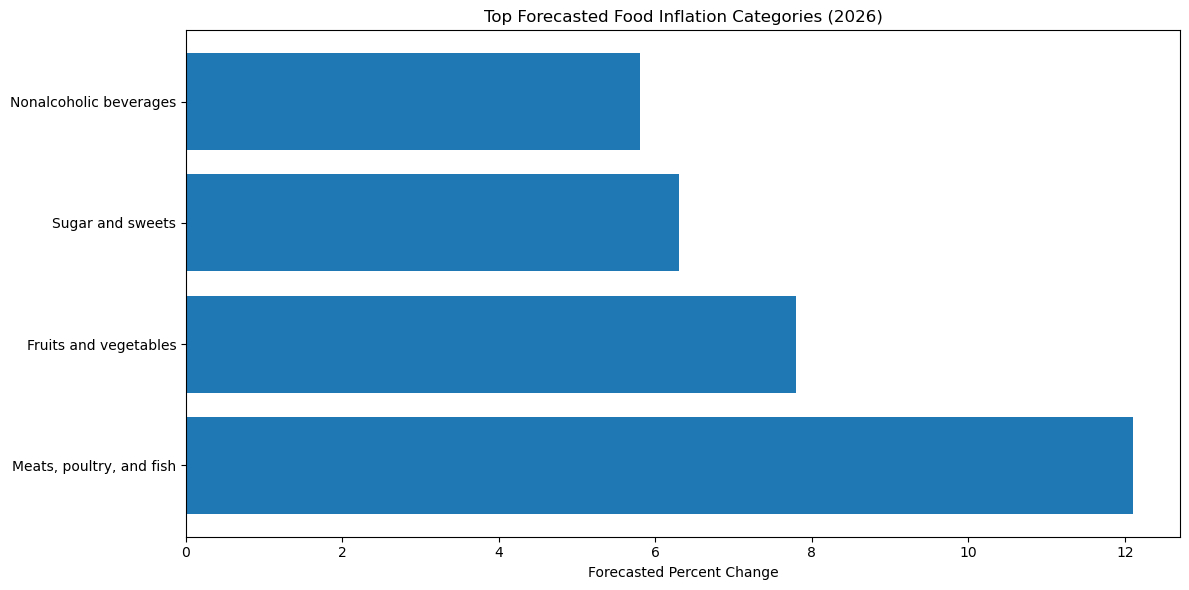

In [8]:
top_forecasts = midpoint_2026.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_forecasts["Mid-level"].fillna(
        top_forecasts["Aggregate"]
    ),
    top_forecasts["Value"]
)

plt.title("Top Forecasted Food Inflation Categories (2026)")
plt.xlabel("Forecasted Percent Change")
plt.tight_layout()

plt.show()

In [9]:
forecast[
    forecast["Attribute"].str.contains(
        "Upper bound",
        na=False
    )
].head()

,Top-level,Aggregate,Mid-level,Low-level,Disaggregate,Attribute,Unit,Value
10,All food,NaN,NaN,NaN,NaN,Upper bound of prediction interval 2026,Percent change,4.7
21,All food,Food away from home,NaN,NaN,NaN,Upper bound of prediction interval 2026,Percent change,4.2
32,All food,Food at home,NaN,NaN,NaN,Upper bound of prediction interval 2026,Percent change,5.2
43,All food,Food at home,"Meats, poultry, and fish",NaN,NaN,Upper bound of prediction interval 2026,Percent change,9.4
54,All food,Food at home,"Meats, poultry, and fish",Meats,NaN,Upper bound of prediction interval 2026,Percent change,11.6


In [10]:
forecast[
    forecast["Attribute"].str.contains(
        "Lower bound",
        na=False
    )
].head()

,Top-level,Aggregate,Mid-level,Low-level,Disaggregate,Attribute,Unit,Value
8,All food,NaN,NaN,NaN,NaN,Lower bound of prediction interval 2026,Percent change,2.2
19,All food,Food away from home,NaN,NaN,NaN,Lower bound of prediction interval 2026,Percent change,2.8
30,All food,Food at home,NaN,NaN,NaN,Lower bound of prediction interval 2026,Percent change,1.3
41,All food,Food at home,"Meats, poultry, and fish",NaN,NaN,Lower bound of prediction interval 2026,Percent change,3.0
52,All food,Food at home,"Meats, poultry, and fish",Meats,NaN,Lower bound of prediction interval 2026,Percent change,3.4


In [11]:
midpoint = forecast[
    forecast["Attribute"] == "Mid point of prediction interval 2026"
].copy()

lower = forecast[
    forecast["Attribute"] == "Lower bound of prediction interval 2026"
].copy()

upper = forecast[
    forecast["Attribute"] == "Upper bound of prediction interval 2026"
].copy()

In [12]:
print(len(midpoint))
print(len(lower))
print(len(upper))

22
22
22


In [13]:
uncertainty = midpoint.copy()

uncertainty["lower_bound"] = lower["Value"].values
uncertainty["upper_bound"] = upper["Value"].values

uncertainty["uncertainty_range"] = (
    uncertainty["upper_bound"]
    - uncertainty["lower_bound"]
)

uncertainty.head()

,Top-level,Aggregate,Mid-level,Low-level,Disaggregate,Attribute,Unit,Value,lower_bound,upper_bound,uncertainty_range
9,All food,NaN,NaN,NaN,NaN,Mid point of prediction interval 2026,Percent change,3.4,2.2,4.7,2.5
20,All food,Food away from home,NaN,NaN,NaN,Mid point of prediction interval 2026,Percent change,3.5,2.8,4.2,1.4
31,All food,Food at home,NaN,NaN,NaN,Mid point of prediction interval 2026,Percent change,3.2,1.3,5.2,3.9
42,All food,Food at home,"Meats, poultry, and fish",NaN,NaN,Mid point of prediction interval 2026,Percent change,6.1,3.0,9.4,6.4
53,All food,Food at home,"Meats, poultry, and fish",Meats,NaN,Mid point of prediction interval 2026,Percent change,7.4,3.4,11.6,8.2


In [14]:
uncertainty[
    [
        "Aggregate",
        "Mid-level",
        "Value",
        "lower_bound",
        "upper_bound",
        "uncertainty_range"
    ]
].sort_values(
    "uncertainty_range",
    ascending=False
).head(10)

,Aggregate,Mid-level,Value,lower_bound,upper_bound,uncertainty_range
119,Food at home,Eggs,-29.8,-38.8,-18.3,20.5
64,Food at home,"Meats, poultry, and fish",12.1,6.6,18.1,11.5
53,Food at home,"Meats, poultry, and fish",7.4,3.4,11.6,8.2
185,Food at home,Fruits and vegetables,7.8,3.9,11.9,8.0
75,Food at home,"Meats, poultry, and fish",1.5,-2.2,5.2,7.4
42,Food at home,"Meats, poultry, and fish",6.1,3.0,9.4,6.4
141,Food at home,Fats and oils,-1.6,-4.6,1.6,6.2
97,Food at home,"Meats, poultry, and fish",0.5,-2.3,3.4,5.7
174,Food at home,Fruits and vegetables,1.8,-0.9,4.7,5.6
163,Food at home,Fruits and vegetables,5.0,2.3,7.8,5.5


In [16]:
uncertainty.to_csv("../dashboard/forecast_uncertainty.csv", index=False)

print("Forecast uncertainty exported successfully")

Forecast uncertainty exported successfully
